In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Colab: extract and merge Drive folder 'dataset' -> /content/dataset/combined/{yes,no}
from pathlib import Path
import shutil, os
from google.colab import drive
from PIL import Image

# 1) Mount Drive
drive.mount('/content/drive')

# 2) Set Drive folder path (change if different)
DRIVE_DATASET = Path('/content/drive/MyDrive/dataset')  # <- your Drive folder named 'dataset'

# 3) Where to put the combined dataset inside Colab VM
OUT_ROOT = Path('/content/dataset')
COMBINED = OUT_ROOT / 'combined'
YES_OUT = COMBINED / 'yes'
NO_OUT  = COMBINED / 'no'
YES_OUT.mkdir(parents=True, exist_ok=True)
NO_OUT.mkdir(parents=True, exist_ok=True)

# 4) Find brain_tumor_dataset_* folders inside DRIVE_DATASET
candidates = sorted([p for p in DRIVE_DATASET.iterdir() if p.is_dir() and p.name.startswith('brain_tumor_dataset_')])
print("Found dataset folders:", [str(p) for p in candidates])

def merge_src(src_folder):
    for label in ('yes','no'):
        src = Path(src_folder) / label
        if not src.exists():
            print(f"Warning: {src} not found")
            continue
        dest_dir = YES_OUT if label=='yes' else NO_OUT
        for f in src.iterdir():
            if f.is_file():
                dest = dest_dir / f.name
                # avoid filename collisions
                if dest.exists():
                    base, ext = os.path.splitext(f.name)
                    i = 1
                    while (dest_dir / f"{base}__dup{i}{ext}").exists():
                        i += 1
                    dest = dest_dir / f"{base}__dup{i}{ext}"
                shutil.copy2(f, dest)

# 5) Merge all found datasets
if not candidates:
    print("No brain_tumor_dataset_* folders found inside", DRIVE_DATASET)
else:
    for p in candidates:
        merge_src(p)

# 6) Quick corrupted-image check (optional)
def find_corrupt(folder):
    bad=[]
    for p in Path(folder).glob('*'):
        if p.is_file():
            try:
                img = Image.open(p)
                img.verify()
            except Exception:
                bad.append(str(p))
    return bad

bad_yes = find_corrupt(YES_OUT)
bad_no  = find_corrupt(NO_OUT)
print(f"Final counts -> yes: {len(list(YES_OUT.glob('*')))}, no: {len(list(NO_OUT.glob('*')))}")
print("Corrupted yes:", len(bad_yes), "Corrupted no:", len(bad_no))
if bad_yes or bad_no:
    print("Examples of corrupted files:", (bad_yes+bad_no)[:5])

print("Combined dataset ready at:", COMBINED)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found dataset folders: ['/content/drive/MyDrive/dataset/brain_tumor_dataset_1', '/content/drive/MyDrive/dataset/brain_tumor_dataset_2']
Final counts -> yes: 311, no: 211
Corrupted yes: 0 Corrupted no: 0
Combined dataset ready at: /content/dataset/combined


# Create stratified train / val / test folders (70/15/15)

In [ ]:
# STEP 1: create stratified splits
import os, shutil, random
from pathlib import Path
from sklearn.model_selection import train_test_split

random.seed(123)

DATA_DIR = Path("dataset/combined")   # change if needed
OUT_ROOT = Path("dataset/splits")     # will create train/val/test here
OUT_ROOT.mkdir(parents=True, exist_ok=True)

labels = ["yes", "no"]
filepaths = []
y = []

for lab in labels:
    folder = DATA_DIR / lab
    for p in folder.glob("*"):
        if p.is_file():
            filepaths.append(str(p))
            y.append(lab)

# first split train vs temp (train 70%, temp 30%)
train_files, temp_files, train_y, temp_y = train_test_split(
    filepaths, y, stratify=y, test_size=0.30, random_state=123
)

# split temp into val and test equally -> each 15% overall
val_files, test_files, val_y, test_y = train_test_split(
    temp_files, temp_y, stratify=temp_y, test_size=0.5, random_state=123
)

def copy_to_split(file_list, label_list, split_name):
    for fp, lab in zip(file_list, label_list):
        dest = OUT_ROOT / split_name / lab
        dest.mkdir(parents=True, exist_ok=True)
        src = Path(fp)
        # handle collisions by adding suffix
        dst = dest / src.name
        if dst.exists():
            base, ext = os.path.splitext(src.name)
            i=1
            while (dest / f"{base}__dup{i}{ext}").exists():
                i+=1
            dst = dest / f"{base}__dup{i}{ext}"
        shutil.copy2(src, dst)

copy_to_split(train_files, train_y, "train")
copy_to_split(val_files, val_y, "val")
copy_to_split(test_files, test_y, "test")

# Print counts
for s in ["train","val","test"]:
    print(s, {lab: len(list((OUT_ROOT/s/lab).glob("*"))) for lab in labels})


train {'yes': 217, 'no': 148}
val {'yes': 47, 'no': 31}
test {'yes': 47, 'no': 32}


# Build tf.data datasets (with augmentation & preprocessing)

In [ ]:
# STEP 2: build tf.data datasets
import tensorflow as tf
from tensorflow.keras import layers

SPLIT_DIR = "dataset/splits"
IMG_SIZE = (224,224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE
SEED = 123

train_ds = tf.keras.utils.image_dataset_from_directory(
    SPLIT_DIR + "/train",
    labels="inferred",
    label_mode="int",   # 0/1
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    SPLIT_DIR + "/val",
    labels="inferred",
    label_mode="int",
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    SPLIT_DIR + "/test",
    labels="inferred",
    label_mode="int",
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    shuffle=False
)

# Prefetch and caching
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

# Data augmentation as a layer (applied on GPU when model trains)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.08),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomContrast(0.08),
])


Found 365 files belonging to 2 classes.
Found 78 files belonging to 2 classes.
Found 79 files belonging to 2 classes.


# Compute class weights (to handle imbalance)

In [ ]:
# STEP 3: compute class weights for training
import numpy as np
from sklearn.utils import class_weight

# get labels from train_ds (since label_mode=int we can extract)
train_labels = np.concatenate([y.numpy() for x,y in train_ds], axis=0)
classes = np.unique(train_labels)
cw = class_weight.compute_class_weight(class_weight='balanced', classes=classes, y=train_labels)
class_weight_dict = {int(k): float(v) for k,v in zip(classes, cw)}
print("Class weights:", class_weight_dict)


Class weights: {0: 1.2331081081081081, 1: 0.8410138248847926}


# Build & compile model (EfficientNetB0 transfer learning)

In [ ]:
# STEP 4: build model
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

def build_model(img_size=IMG_SIZE, num_classes=1, dropout_rate=0.3):
    inputs = layers.Input(shape=img_size + (3,))
    x = data_augmentation(inputs)
    x = preprocess_input(x)
    base = EfficientNetB0(weights="imagenet", include_top=False, input_tensor=x)
    base.trainable = False  # freeze initially
    x = layers.GlobalAveragePooling2D(name="gap")(base.output)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    # binary classification: single unit + sigmoid
    outputs = layers.Dense(1, activation="sigmoid")(x)
    model = models.Model(inputs, outputs)
    return model

model = build_model()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

model.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ sequential[0][0]  │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati

 Total params: 4,213,668 (16.07 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

# Train with callbacks & optional fine-tuning

In [ ]:
# STEP 5: training (head training, then fine-tune)
import datetime
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

LOG_DIR = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
ckpt = ModelCheckpoint("best_brain_tumor.h5", monitor="val_auc", mode="max", save_best_only=True, verbose=1)
es = EarlyStopping(monitor="val_auc", mode="max", patience=8, restore_best_weights=True)
rlr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1)

EPOCHS_HEAD = 12
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_HEAD,
    class_weight=class_weight_dict,
    callbacks=[ckpt, es, rlr]
)

# Fine-tune: unfreeze last layers of base
base_model = model.get_layer(index=2)  # EfficientNetB0 base is second layer after Input and augmentation+preproc; adapt if different
base_model.trainable = True

# Freeze early layers to avoid destroying learned features
fine_tune_at = int(len(base_model.layers) * 0.6)  # unfreeze last 40% layers
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

EPOCHS_FINE = 12
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINE,
    class_weight=class_weight_dict,
    callbacks=[ckpt, es, rlr]
)


Epoch 1/12
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6029 - auc: 0.6756 - loss: 0.6424
Epoch 1: val_auc improved from -inf to 0.94097, saving model to best_brain_tumor.h5


12/12 ━━━━━━━━━━━━━━━━━━━━ 57s 3s/step - accuracy: 0.6105 - auc: 0.6832 - loss: 0.6371 - val_accuracy: 0.8462 - val_auc: 0.9410 - val_loss: 0.3590 - learning_rate: 0.0010
Epoch 2/12
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8445 - auc: 0.9012 - loss: 0.4054
Epoch 2: val_auc improved from 0.94097 to 0.95024, saving model to best_brain_tumor.h5


12/12 ━━━━━━━━━━━━━━━━━━━━ 79s 3s/step - accuracy: 0.8430 - auc: 0.9010 - loss: 0.4053 - val_accuracy: 0.8974 - val_auc: 0.9502 - val_loss: 0.3227 - learning_rate: 0.0010
Epoch 3/12
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8688 - auc: 0.9303 - loss: 0.3387
Epoch 3: val_auc improved from 0.95024 to 0.96054, saving model to best_brain_tumor.h5


12/12 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.8688 - auc: 0.9304 - loss: 0.3382 - val_accuracy: 0.8974 - val_auc: 0.9605 - val_loss: 0.2720 - learning_rate: 0.0010
Epoch 4/12
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8866 - auc: 0.9442 - loss: 0.3051
Epoch 4: val_auc improved from 0.96054 to 0.96877, saving model to best_brain_tumor.h5


12/12 ━━━━━━━━━━━━━━━━━━━━ 39s 3s/step - accuracy: 0.8856 - auc: 0.9436 - loss: 0.3064 - val_accuracy: 0.8974 - val_auc: 0.9688 - val_loss: 0.2378 - learning_rate: 0.0010
Epoch 5/12
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8884 - auc: 0.9622 - loss: 0.2685
Epoch 5: val_auc improved from 0.96877 to 0.97426, saving model to best_brain_tumor.h5


12/12 ━━━━━━━━━━━━━━━━━━━━ 38s 3s/step - accuracy: 0.8885 - auc: 0.9618 - loss: 0.2689 - val_accuracy: 0.9103 - val_auc: 0.9743 - val_loss: 0.2237 - learning_rate: 0.0010
Epoch 6/12
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9024 - auc: 0.9565 - loss: 0.2757
Epoch 6: val_auc improved from 0.97426 to 0.98284, saving model to best_brain_tumor.h5


12/12 ━━━━━━━━━━━━━━━━━━━━ 43s 4s/step - accuracy: 0.9021 - auc: 0.9566 - loss: 0.2744 - val_accuracy: 0.9231 - val_auc: 0.9828 - val_loss: 0.1870 - learning_rate: 0.0010
Epoch 7/12
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9386 - auc: 0.9844 - loss: 0.1838
Epoch 7: val_auc did not improve from 0.98284
12/12 ━━━━━━━━━━━━━━━━━━━━ 37s 3s/step - accuracy: 0.9374 - auc: 0.9839 - loss: 0.1854 - val_accuracy: 0.9359 - val_auc: 0.9825 - val_loss: 0.1817 - learning_rate: 0.0010
Epoch 8/12
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8853 - auc: 0.9601 - loss: 0.2642
Epoch 8: val_auc did not improve from 0.98284
12/12 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.8872 - auc: 0.9605 - loss: 0.2625 - val_accuracy: 0.9103 - val_auc: 0.9811 - val_loss: 0.1874 - learning_rate: 0.0010
Epoch 9/12
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9268 - auc: 0.9816 - loss: 0.1766
Epoch 9: val_auc did not improve from 0.98284
12/12 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.9261 

12/12 ━━━━━━━━━━━━━━━━━━━━ 39s 3s/step - accuracy: 0.9089 - auc: 0.9683 - loss: 0.2292 - val_accuracy: 0.9231 - val_auc: 0.9835 - val_loss: 0.1817 - learning_rate: 0.0010
Epoch 11/12
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8966 - auc: 0.9582 - loss: 0.2621
Epoch 11: val_auc improved from 0.98353 to 0.98730, saving model to best_brain_tumor.h5


12/12 ━━━━━━━━━━━━━━━━━━━━ 39s 3s/step - accuracy: 0.8982 - auc: 0.9592 - loss: 0.2588 - val_accuracy: 0.9231 - val_auc: 0.9873 - val_loss: 0.1621 - learning_rate: 0.0010
Epoch 12/12
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9072 - auc: 0.9741 - loss: 0.2116
Epoch 12: val_auc did not improve from 0.98730
12/12 ━━━━━━━━━━━━━━━━━━━━ 38s 3s/step - accuracy: 0.9078 - auc: 0.9742 - loss: 0.2112 - val_accuracy: 0.9231 - val_auc: 0.9873 - val_loss: 0.1831 - learning_rate: 0.0010


AttributeError: 'Rescaling' object has no attribute 'layers'

In [ ]:
# print layers to locate the EfficientNet/ base model inside the full model
for i, layer in enumerate(model.layers):
    print(i, layer.name, type(layer))


0 input_layer <class 'keras.src.layers.core.input_layer.InputLayer'>
1 sequential <class 'keras.src.models.sequential.Sequential'>
2 rescaling <class 'keras.src.layers.preprocessing.rescaling.Rescaling'>
3 normalization <class 'keras.src.layers.preprocessing.normalization.Normalization'>
4 rescaling_1 <class 'keras.src.layers.preprocessing.rescaling.Rescaling'>
5 stem_conv_pad <class 'keras.src.layers.reshaping.zero_padding2d.ZeroPadding2D'>
6 stem_conv <class 'keras.src.layers.convolutional.conv2d.Conv2D'>
7 stem_bn <class 'keras.src.layers.normalization.batch_normalization.BatchNormalization'>
8 stem_activation <class 'keras.src.layers.activations.activation.Activation'>
9 block1a_dwconv <class 'keras.src.layers.convolutional.depthwise_conv2d.DepthwiseConv2D'>
10 block1a_bn <class 'keras.src.layers.normalization.batch_normalization.BatchNormalization'>
11 block1a_activation <class 'keras.src.layers.activations.activation.Activation'>
12 block1a_se_squeeze <class 'keras.src.layers.poo

In [ ]:
# Safe fine-tuning for your current model (works with the layer listing you posted)
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# --- config: adjust if desired ---
PCT_FROZEN = 0.6      # keep first 60% of backbone frozen, unfreeze last 40%
FINE_LR = 1e-5
EPOCHS_FINE = 12

# --- find backbone start/end by layer names observed in your model ---
layer_names = [layer.name for layer in model.layers]
# Based on your listing, backbone begins at 'stem_conv_pad' and ends at 'top_activation'
try:
    backbone_start_idx = layer_names.index("stem_conv_pad")
    backbone_end_idx   = layer_names.index("top_activation")  # inclusive
except ValueError:
    # fallback: try to find 'top_conv' or 'gap' as endpoints
    backbone_start_idx = next((i for i,n in enumerate(layer_names) if "stem_conv" in n or "stem" in n), None)
    backbone_end_idx   = next((i for i,n in enumerate(layer_names[::-1]) if "top_activation" in n or "top_conv" in n or "top" in n), None)
    if backbone_end_idx is not None:
        backbone_end_idx = len(layer_names) - 1 - backbone_end_idx
    if backbone_start_idx is None or backbone_end_idx is None:
        raise RuntimeError("Could not auto-detect backbone start/end. Please check model.summary() and adjust names in the code.")

print(f"Detected backbone start index: {backbone_start_idx} ({layer_names[backbone_start_idx]})")
print(f"Detected backbone end   index: {backbone_end_idx} ({layer_names[backbone_end_idx]})")

# compute boundary for freezing (relative to backbone)
n_backbone_layers = backbone_end_idx - backbone_start_idx + 1
freeze_up_to = backbone_start_idx + int(n_backbone_layers * PCT_FROZEN)
print(f"Backbone has {n_backbone_layers} layers. Freezing layers < index {freeze_up_to} (keeps first {int(PCT_FROZEN*100)}%)")

# Apply trainable flags:
for i, layer in enumerate(model.layers):
    # keep preprocessing/augmentation layers frozen (commonly at the start)
    if i < backbone_start_idx:
        layer.trainable = False
    # Freeze early backbone layers
    elif backbone_start_idx <= i < freeze_up_to:
        layer.trainable = False
    # Unfreeze remaining backbone + everything after backbone (head)
    else:
        layer.trainable = True

# Print summary of what we changed (small list)
trainable_layers = [f"{i}:{layer.name}" for i,layer in enumerate(model.layers) if layer.trainable]
frozen_layers    = [f"{i}:{layer.name}" for i,layer in enumerate(model.layers) if not layer.trainable]
print(f"\nTrainable layers count: {len(trainable_layers)}")
print("Example trainable layers (first 30):")
print(trainable_layers[:30])
print("\nFrozen layers count:", len(frozen_layers))
print("Example frozen layers (first 30):")
print(frozen_layers[:30])

# --- Recompile model with low LR for fine-tuning ---
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=FINE_LR),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

# --- Callbacks (reuse existing names if available; adjust filename to .keras if you prefer) ---
ckpt = ModelCheckpoint("best_brain_tumor.keras", monitor="val_auc", mode="max", save_best_only=True, verbose=1)
es = EarlyStopping(monitor="val_auc", mode="max", patience=6, restore_best_weights=True)
rlr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1)

# --- Continue training ---
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINE,
    class_weight=class_weight_dict if 'class_weight_dict' in globals() else None,
    callbacks=[ckpt, es, rlr]
)


Detected backbone start index: 5 (stem_conv_pad)
Detected backbone end   index: 238 (top_activation)
Backbone has 234 layers. Freezing layers < index 145 (keeps first 60%)

Trainable layers count: 99
Example trainable layers (first 30):
['145:block5b_project_conv', '146:block5b_project_bn', '147:block5b_drop', '148:block5b_add', '149:block5c_expand_conv', '150:block5c_expand_bn', '151:block5c_expand_activation', '152:block5c_dwconv', '153:block5c_bn', '154:block5c_activation', '155:block5c_se_squeeze', '156:block5c_se_reshape', '157:block5c_se_reduce', '158:block5c_se_expand', '159:block5c_se_excite', '160:block5c_project_conv', '161:block5c_project_bn', '162:block5c_drop', '163:block5c_add', '164:block6a_expand_conv', '165:block6a_expand_bn', '166:block6a_expand_activation', '167:block6a_dwconv_pad', '168:block6a_dwconv', '169:block6a_bn', '170:block6a_activation', '171:block6a_se_squeeze', '172:block6a_se_reshape', '173:block6a_se_reduce', '174:block6a_se_expand']

Frozen layers coun

## A — Inspect progress & evaluate on test set

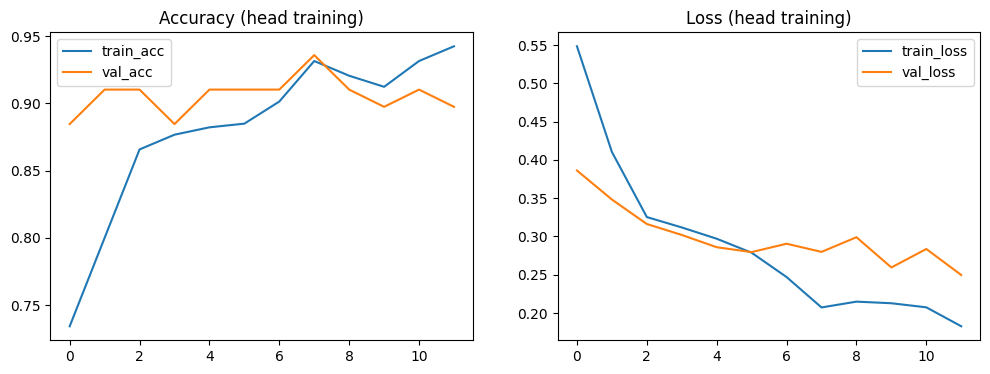

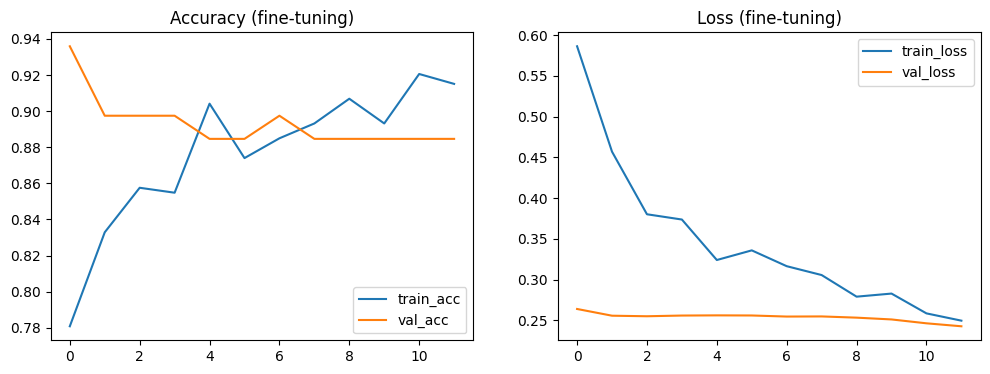

In [ ]:
# 1) Plot training curves (use history and history_fine returned earlier)
import matplotlib.pyplot as plt
def plot_combined(hist1, hist2=None):
    # hist1 = history (head), hist2 = history_fine (fine-tune) — either may be None
    def plot(h, title_suffix=""):
        if h is None: return
        plt.figure(figsize=(12,4))
        plt.subplot(1,2,1)
        plt.plot(h.history.get("accuracy",[]), label="train_acc")
        plt.plot(h.history.get("val_accuracy",[]), label="val_acc")
        plt.legend(); plt.title("Accuracy " + title_suffix)
        plt.subplot(1,2,2)
        plt.plot(h.history.get("loss",[]), label="train_loss")
        plt.plot(h.history.get("val_loss",[]), label="val_loss")
        plt.legend(); plt.title("Loss " + title_suffix)
        plt.show()
    plot(hist1, "(head training)")
    plot(hist2, "(fine-tuning)")
# call this with the variables you used:
plot_combined(history if 'history' in globals() else None, history_fine if 'history_fine' in globals() else None)


In [ ]:
# 2) Evaluate on the test set (get final metrics)
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# load best weights (your fine-tune saved best_brain_tumor.keras)
try:
    model.load_weights("best_brain_tumor.keras")
except Exception:
    print("Could not load .keras checkpoint; using current model weights.")

# predict on test set
y_true = np.concatenate([y.numpy() for x,y in test_ds], axis=0)
y_probs = model.predict(test_ds).ravel()
y_pred = (y_probs >= 0.5).astype(int)

print("Test ROC AUC:", roc_auc_score(y_true, y_probs))
print("Confusion matrix:")
print(confusion_matrix(y_true, y_pred))
print("Classification report:")
print(classification_report(y_true, y_pred, digits=4))


3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step
Test ROC AUC: 0.9893617021276596
Confusion matrix:
[[32  0]
 [ 2 45]]
Classification report:
              precision    recall  f1-score   support

           0     0.9412    1.0000    0.9697        32
           1     1.0000    0.9574    0.9783        47

    accuracy                         0.9747        79
   macro avg     0.9706    0.9787    0.9740        79
weighted avg     0.9762    0.9747    0.9748        79



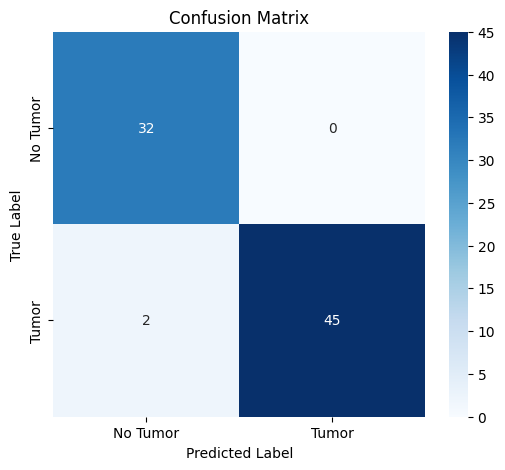

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)
labels = ["No Tumor", "Tumor"]

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


# Save the final model properly (Keras format)

In [ ]:
model.save("brain_tumor_classifier.keras")
print("Model saved as brain_tumor_classifier.keras")


Model saved as brain_tumor_classifier.keras


In [ ]:
import shutil

# Path to your model file in Colab
src_path = "/content/brain_tumor_classifier.keras"

# Destination folder in Drive
dst_path = "/content/drive/MyDrive/brain_tumor_classifier.keras"

# Copy file
shutil.copy(src_path, dst_path)

print("Model uploaded to Drive at:", dst_path)


Model uploaded to Drive at: /content/drive/MyDrive/brain_tumor_classifier.keras


In [ ]:
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing import image
from skimage import measure

IMG_SIZE = (224,224)
LAST_CONV_LAYER = "top_conv"   # your model's last conv layer (confirmed earlier)

def make_gradcam_heatmap(img_array, model, last_conv_layer_name=LAST_CONV_LAYER, eps=1e-8):
    """
    img_array: preprocessed numpy array shape (1,h,w,3)
    returns: heatmap (h,w) normalized 0..1
    """
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        # for binary sigmoid output we use predictions[:, 0]
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)  # shape (1, H, W, C)
    # Global average pooling on gradients
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
    conv_outputs = conv_outputs[0]  # (H, W, C)

    # weight the channels by gradient importance
    weighted = conv_outputs * pooled_grads[tf.newaxis, tf.newaxis, :]
    heatmap = tf.reduce_sum(weighted, axis=-1)

    # relu & normalize
    heatmap = tf.maximum(heatmap, 0)
    max_val = tf.reduce_max(heatmap)
    heatmap = heatmap / (max_val + eps)
    return heatmap.numpy()

def load_and_prep(img_path, img_size=IMG_SIZE):
    img = image.load_img(img_path, target_size=img_size)
    arr = image.img_to_array(img)
    inp = np.expand_dims(arr.copy(), axis=0)
    inp = preprocess_input(inp)   # use same preprocess as training
    return arr.astype(np.uint8), inp

def heatmap_to_overlay(orig_arr, heatmap, alpha=0.5, colormap=cv2.COLORMAP_JET):
    # heatmap: (h,w) float 0..1, orig_arr: HxWx3 uint8
    heatmap_uint8 = np.uint8(255 * heatmap)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, colormap)  # BGR
    # ensure same size
    heatmap_color = cv2.resize(heatmap_color, (orig_arr.shape[1], orig_arr.shape[0]))
    overlay_bgr = cv2.addWeighted(cv2.cvtColor(orig_arr, cv2.COLOR_RGB2BGR), 1-alpha, heatmap_color, alpha, 0)
    overlay_rgb = cv2.cvtColor(overlay_bgr, cv2.COLOR_BGR2RGB)
    return overlay_rgb, heatmap_color

def get_bounding_box_from_heatmap(heatmap, threshold=0.4, min_area=50):
    """
    heatmap: float 0..1 numpy (h,w)
    returns: bbox tuple (x_min,y_min,x_max,y_max) in heatmap coordinates or None if not found
    """
    # Threshold the heatmap
    mask = (heatmap >= threshold).astype(np.uint8)
    # Label connected components
    labels = measure.label(mask, connectivity=2)
    if labels.max() == 0:
        return None, mask  # no regions
    # find largest component by area
    props = measure.regionprops(labels)
    areas = [p.area for p in props]
    max_idx = int(np.argmax(areas))
    if areas[max_idx] < min_area:
        return None, mask
    bbox = props[max_idx].bbox  # (min_row, min_col, max_row, max_col)
    # Convert to x,y coordinates (x_min,y_min,x_max,y_max)
    y_min, x_min, y_max, x_max = bbox
    return (x_min, y_min, x_max, y_max), mask

def localize_tumor(img_path, model, threshold=0.4, display=True):
    orig_arr, inp = load_and_prep(img_path)
    heatmap = make_gradcam_heatmap(inp, model)   # shape (h,w)
    # Resize heatmap to original image size
    heatmap_resized = cv2.resize(heatmap, (orig_arr.shape[1], orig_arr.shape[0]))
    overlay_rgb, heatmap_color = heatmap_to_overlay(orig_arr, heatmap_resized, alpha=0.5)
    bbox, mask = get_bounding_box_from_heatmap(heatmap_resized, threshold=threshold)
    # draw bbox on overlay
    overlay_with_box = overlay_rgb.copy()
    img_with_box = orig_arr.copy()
    if bbox is not None:
        x_min, y_min, x_max, y_max = bbox
        # draw rectangle on overlay and original
        cv2.rectangle(overlay_with_box, (x_min, y_min), (x_max, y_max), (255,255,0), 2)  # cyan on RGB image
        cv2.rectangle(img_with_box, (x_min, y_min), (x_max, y_max), (255,255,0), 2)
    if display:
        plt.figure(figsize=(14,6))
        plt.subplot(1,3,1); plt.imshow(orig_arr); plt.title("Original"); plt.axis("off")
        plt.subplot(1,3,2); plt.imshow(overlay_rgb); plt.title("Grad-CAM Overlay"); plt.axis("off")
        plt.subplot(1,3,3);
        if bbox is not None:
            # show overlay with bbox
            plt.imshow(overlay_with_box)
            plt.title(f"Detected bbox: {bbox}")
        else:
            plt.imshow(overlay_rgb)
            plt.title("No region above threshold")
        plt.axis("off")
        plt.show()
    return {
        "heatmap": heatmap_resized,    # float 0..1
        "overlay": overlay_rgb,        # RGB image uint8
        "bbox": bbox,                  # (x_min,y_min,x_max,y_max) or None
        "mask": mask                   # binary mask used for region extraction (same size as heatmap_resized)
    }

# Example usage (replace with your image path):
# result = localize_tumor("dataset/splits/test/yes/sample.jpg", model, threshold=0.4)
